## 1. Data Cleaning & Feature Engineering

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Telco Customer Churn dataset
# Source: IBM Sample Data Sets
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# --- STEP 1: DATA TYPE ENFORCEMENT & NULL HANDLING ---
# 'TotalCharges' contains empty strings (" ") which cause it to be read as an object.
# We cast to numeric, coercing errors to NaN to facilitate statistical imputation.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Imputation Strategy: Missing values in 'TotalCharges' typically correspond to 
# new customers (tenure = 0). We replace NaNs with 'MonthlyCharges' as a proxy.
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# --- STEP 2: FEATURE ENGINEERING & CARDINALITY REDUCTION ---
# Several categorical features contain 'No internet service' as a redundant label.
# To simplify the feature space and reduce dimensionality during encoding, 
# we consolidate this into the 'No' category.
redundant_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in redundant_cols:
    df[col] = df[col].replace({'No internet service': 'No'})

# --- STEP 3: TARGET VARIABLE ENCODING ---
# Convert the target 'Churn' into a binary integer format for compatibility 
# with Scikit-Learn classifiers and to enable correlation analysis.
# Positive Class (1): Churned | Negative Class (0): Retained
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --- STEP 4: DATA DENOISING ---
# 'customerID' is a high-cardinality identifier with no predictive value.
# Dropping it prevents the model from capturing noise and improves generalization.
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# Dataset validation: Ensure the final structure matches expected dimensions
print(f" Cleaned Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

 Cleaned Dataset: 7043 rows, 20 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# --- FEATURE ENGINEERING ---

# 1. Service Density: Quantify customer 'stickiness' via product adoption
# High density usually correlates with higher switching costs (lower churn)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['ServiceCount'] = (df[service_cols] != 'No').sum(axis=1) #Counts the number of 'Yes' responses across key service features, indicating the breadth of services a customer uses.

# 2. Charge Velocity: Average monthly spend over the lifetime of the account
# Used to detect 'Bill Shock' where current charges spike above historical averages
df['ChargeVelocity'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Bill Ratio: Proportion of current bill to total lifetime spend
# Helps differentiate between new accounts and long-term established customers
df['BillRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

# --- EXPORT & LOGGING ---

df.to_csv('telco_processed_phase1.csv', index=False)

print(f"DONE - Feature Engineering Complete. New features: {['ServiceCount', 'ChargeVelocity', 'BillRatio']}")
print(df[['ServiceCount', 'ChargeVelocity', 'BillRatio', 'Churn']].sample(5))

DONE - Feature Engineering Complete. New features: ['ServiceCount', 'ChargeVelocity', 'BillRatio']
      ServiceCount  ChargeVelocity  BillRatio  Churn
840              6       98.380357   0.018148      1
5654             7      105.801408   0.014023      0
1375             1       21.370000   0.023195      0
739              9       91.744521   0.013414      0
5858             1       21.554032   0.014544      0


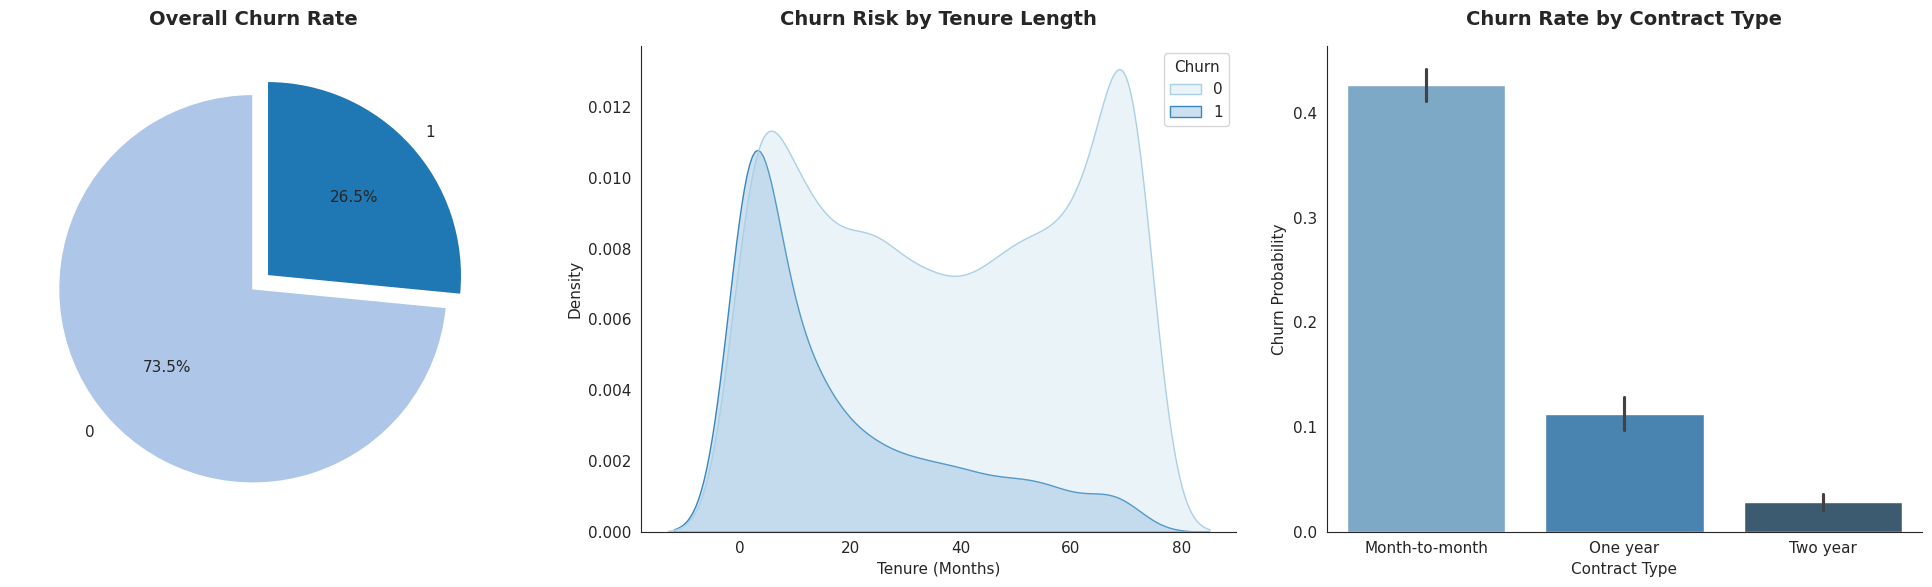

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_global_churn_overview(df):
    """
    Generates a three-panel dashboard visualizing global churn metrics:
    1. Proportional breakdown (Pie Chart)
    2. Temporal distribution (KDE Plot)
    3. Categorical drivers (Bar Plot)
    """
    
    # --- Configuration & Styling ---
    sns.set_style("white")
    plt.rcParams.update({'font.size': 11}) # Ensure consistent readability
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # --- 1. Overall Churn Proportion ---
    # Visualizes the class imbalance between churned and retained customers
    df['Churn'].value_counts().plot.pie(
        autopct='%1.1f%%', 
        explode=[0, 0.1], 
        ax=axes[0], 
        colors=['#aec7e8', '#1f77b4'], 
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1} # Sharpens segment edges
    )
    axes[0].set_title('Overall Churn Rate', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_ylabel('') 

    # --- 2. Tenure vs Churn (KDE) ---
    # Identifies high-risk periods within the customer lifecycle
    sns.kdeplot(
        data=df, x='tenure', hue='Churn', 
        fill=True, palette='Blues', ax=axes[1]
    )
    axes[1].set_title('Churn Risk by Tenure Length', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Tenure (Months)')
    axes[1].set_ylabel('Density')

    # --- 3. Contract Influence ---
    # Analyzes how contractual commitment impacts probability of attrition
    sns.barplot(
        x='Contract', y='Churn', data=df, 
        hue='Contract', palette='Blues_d', ax=axes[2], 
        legend=False
    )
    axes[2].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=15)
    axes[2].set_xlabel('Contract Type')
    axes[2].set_ylabel('Churn Probability')

    # --- Final Polish ---
    sns.despine() # Removes top and right spines for a modern look
    plt.tight_layout()
    plt.show()

# Execute visualization
plot_global_churn_overview(df)